In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv"
df = pd.read_csv(url)

print(df.head())

   Campaign_ID              Company Campaign_Type Target_Audience Duration  \
0            1             TechCorp         Email     Women 25-34  30 days   
1            2  Innovate Industries    Influencer     Women 35-44  45 days   
2            3       NexGen Systems  Social Media     Women 25-34  45 days   
3            4  Innovate Industries         Email     Women 25-34  45 days   
4            5  Data Tech Solutions    Influencer       Men 25-34  30 days   

  Channel_Used  Conversion_Rate  Acquisition_Cost     ROI          Location  \
0     Facebook         5.294194              9344   62.94           Houston   
1   Google Ads         3.326375              8783   10.67  Washington, D.C.   
2    Instagram         4.056375              9111   73.20             Miami   
3    Instagram         4.496375              7420   60.92           Seattle   
4   Google Ads         4.405930              2146  138.82           Chicago   

  Language  Clicks  Impressions  Engagement_Score  Custo

In [45]:
print("Rows & Columns:", df.shape)

Rows & Columns: (22029, 16)


In [46]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22029 entries, 0 to 22028
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       22029 non-null  int64  
 1   Company           22029 non-null  object 
 2   Campaign_Type     22029 non-null  object 
 3   Target_Audience   22029 non-null  object 
 4   Duration          22029 non-null  object 
 5   Channel_Used      22029 non-null  object 
 6   Conversion_Rate   22029 non-null  float64
 7   Acquisition_Cost  22029 non-null  int64  
 8   ROI               22029 non-null  float64
 9   Location          22029 non-null  object 
 10  Language          22029 non-null  object 
 11  Clicks            22029 non-null  int64  
 12  Impressions       22029 non-null  int64  
 13  Engagement_Score  22029 non-null  int64  
 14  Customer_Segment  22029 non-null  object 
 15  Date              22029 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

In [48]:
print(df.describe())

        Campaign_ID  Conversion_Rate  Acquisition_Cost           ROI  \
count  22029.000000     22029.000000      22029.000000  22029.000000   
mean   11015.000000         4.757232       5522.740842    182.863648   
std     6359.368876         0.960393       2597.666260    301.619721   
min        1.000000         2.015723       1000.000000    -98.300000   
25%     5508.000000         4.130705       3286.000000     -4.080000   
50%    11015.000000         4.761527       5525.000000     93.650000   
75%    16522.000000         5.429335       7766.000000    247.310000   
max    22029.000000         7.469907       9999.000000   3109.790000   

             Clicks   Impressions  Engagement_Score  
count  22029.000000  22029.000000      22029.000000  
mean    2223.807572  50610.402787          6.582323  
std     1394.166380  28542.979123          1.458804  
min       30.000000   1001.000000          4.000000  
25%     1067.000000  25804.000000          5.000000  
50%     2088.000000  50858.

In [49]:
print("Unique Campaign IDs:", df['Campaign_ID'].nunique())

Unique Campaign IDs: 22029


In [50]:
print("Locations:", df['Location'].unique())
print("Customer Segments:", df['Customer_Segment'].unique())

Locations: ['Houston' 'Washington, D.C.' 'Miami' 'Seattle' 'Chicago' 'Los Angeles'
 'Atlanta' 'Dallas' 'New York' 'San Francisco']
Customer Segments: ['Tech Enthusiasts' 'Foodies' 'Fashionistas' 'Outdoor Adventurers'
 'Health & Wellness']


In [29]:
print(df['Campaign_Type'].value_counts())
print(df['Channel_Used'].value_counts())

Campaign_Type
Display         4450
Search          4441
Social Media    4412
Email           4388
Influencer      4338
Name: count, dtype: int64
Channel_Used
Facebook      3742
Google Ads    3694
Website       3688
Instagram     3649
YouTube       3632
Email         3624
Name: count, dtype: int64


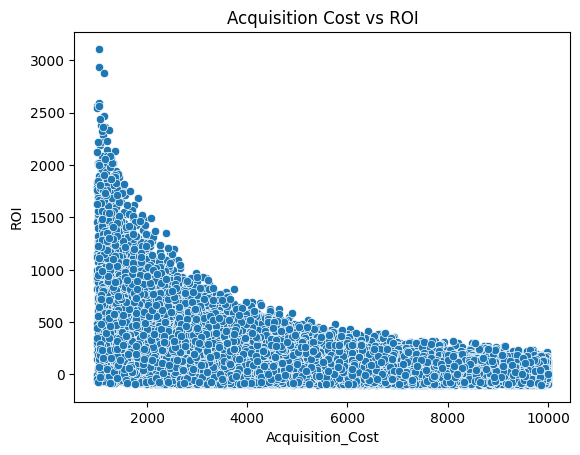

In [30]:
plt.figure()
sns.scatterplot(x='Acquisition_Cost', y='ROI', data=df)
plt.title("Acquisition Cost vs ROI")
plt.show()

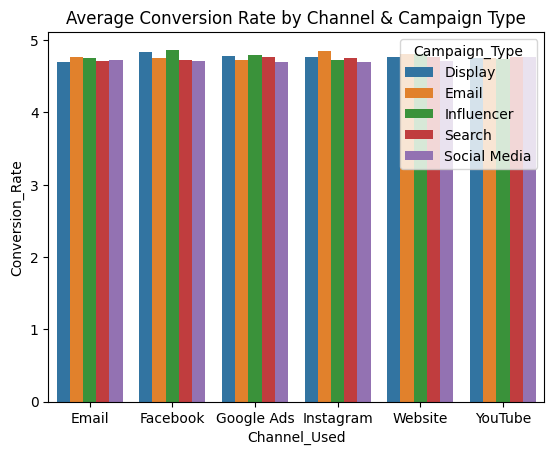

In [31]:
avg_conv = df.groupby(['Channel_Used', 'Campaign_Type'])['Conversion_Rate'].mean().reset_index()

plt.figure()
sns.barplot(x='Channel_Used', y='Conversion_Rate', hue='Campaign_Type', data=avg_conv)
plt.title("Average Conversion Rate by Channel & Campaign Type")
plt.show()

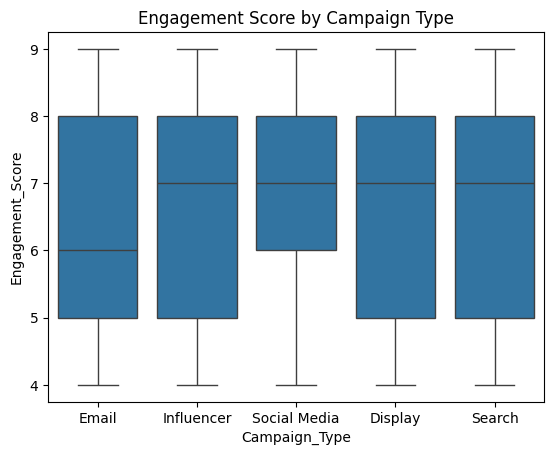

In [32]:
plt.figure()
sns.boxplot(x='Campaign_Type', y='Engagement_Score', data=df)
plt.title("Engagement Score by Campaign Type")
plt.show()

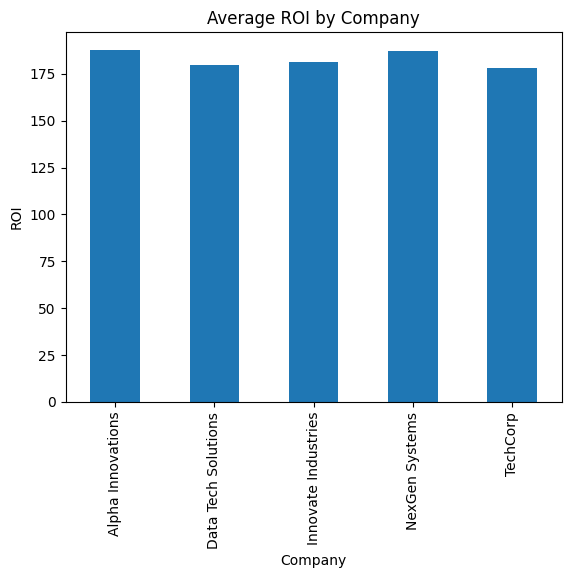

In [33]:
avg_roi = df.groupby('Company')['ROI'].mean()

avg_roi.plot(kind='bar')
plt.title("Average ROI by Company")
plt.ylabel("ROI")
plt.show()

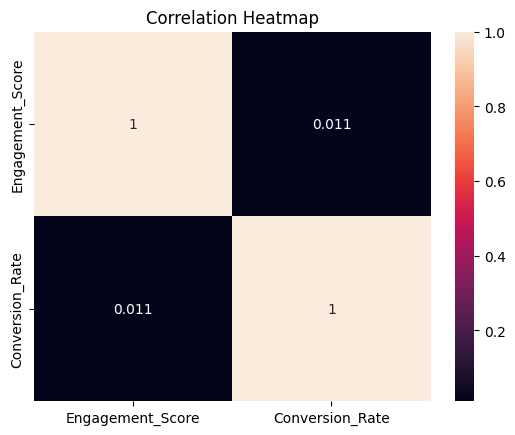

In [34]:
corr = df[['Engagement_Score', 'Conversion_Rate']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

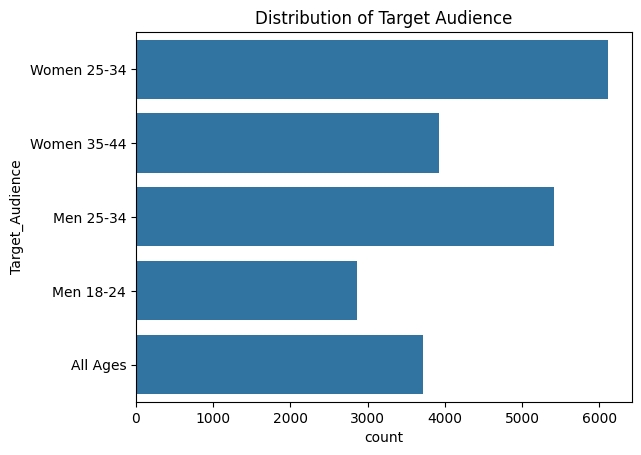

In [35]:
sns.countplot(y='Target_Audience', data=df)
plt.title("Distribution of Target Audience")
plt.show()

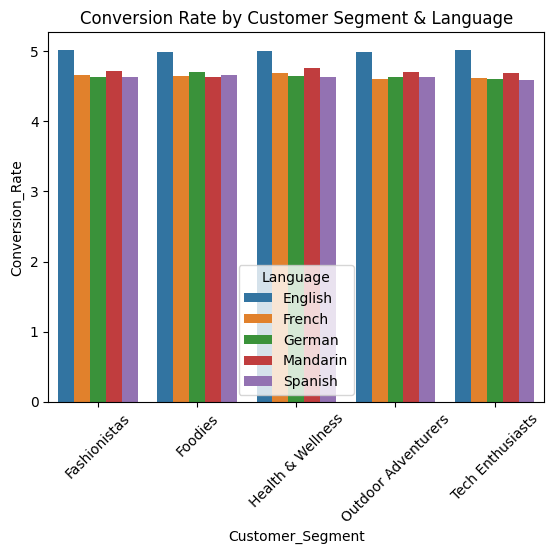

In [36]:
segment_lang = df.groupby(['Customer_Segment', 'Language'])['Conversion_Rate'].mean().reset_index()

sns.barplot(x='Customer_Segment', y='Conversion_Rate', hue='Language', data=segment_lang)
plt.title("Conversion Rate by Customer Segment & Language")
plt.xticks(rotation=45)
plt.show()

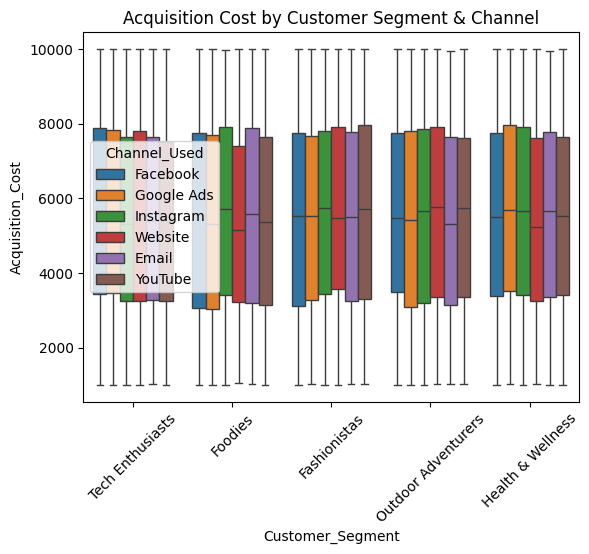

In [37]:
sns.boxplot(x='Customer_Segment', y='Acquisition_Cost', hue='Channel_Used', data=df)
plt.title("Acquisition Cost by Customer Segment & Channel")
plt.xticks(rotation=45)
plt.show()

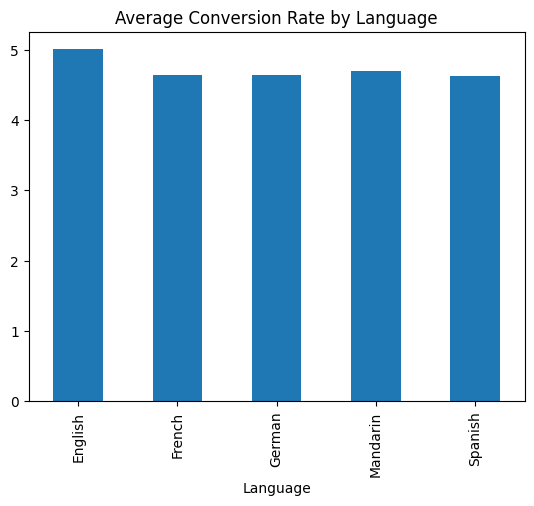

In [38]:
lang_avg = df.groupby('Language')['Conversion_Rate'].mean()

lang_avg.plot(kind='bar')
plt.title("Average Conversion Rate by Language")
plt.show()

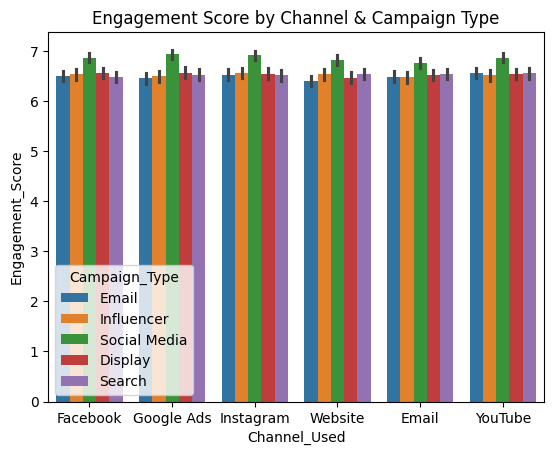

In [39]:
sns.barplot(x='Channel_Used', y='Engagement_Score', hue='Campaign_Type', data=df)
plt.title("Engagement Score by Channel & Campaign Type")
plt.show()

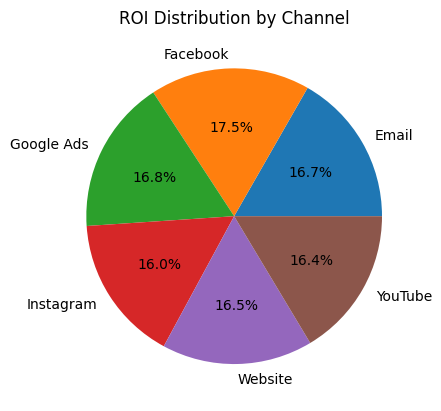

In [40]:
roi_channel = df.groupby('Channel_Used')['ROI'].sum()

plt.pie(roi_channel, labels=roi_channel.index, autopct='%1.1f%%')
plt.title("ROI Distribution by Channel")
plt.show()

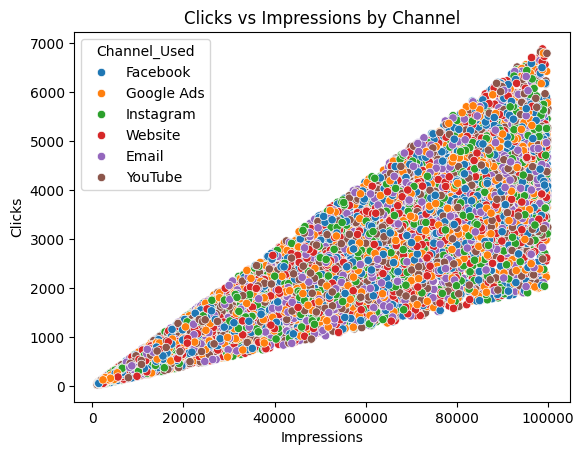

In [41]:
sns.scatterplot(x='Impressions', y='Clicks', hue='Channel_Used', data=df)
plt.title("Clicks vs Impressions by Channel")
plt.show()

In [ ]:
plt.hist(df['Duration'], bins=20)
plt.title("Distribution of Campaign Duration")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

sns.lineplot(x='Date', y='Conversion_Rate', hue='Company', data=df)
plt.title("Conversion Rate over Time by Company")
plt.show()

In [ ]:
sns.lineplot(x='Date', y='Engagement_Score', data=df)
plt.title("Engagement Score Trend Over Time")
plt.show()

In [ ]:
loc_cost = df.groupby('Location')['Acquisition_Cost'].mean()

loc_cost.plot(kind='bar')
plt.title("Acquisition Cost by Location")
plt.show()

In [ ]:
sns.barplot(x='Location', y='Conversion_Rate', hue='Target_Audience', data=df)
plt.title("Conversion Rate by Location & Target Audience")
plt.xticks(rotation=45)
plt.show()

In [ ]:
roi_location = df.groupby('Location')['ROI'].sum()

plt.pie(roi_location, labels=roi_location.index, autopct='%1.1f%%')
plt.title("ROI Proportion by Location")
plt.show()